# Logical CNOT — Transversal

The transversal CNOT applies a physical CNOT between corresponding qubits of
two surface code patches (control and target), implementing the logical CNOT.

Five sub-experiments probe all combinations of logical input/output bases:

| Sub-experiment | Init C | Init T | Meas C | Meas T | Tests |
|---|---|---|---|---|---|
| ZZ_ZZ | Z | Z | Z | Z | Z_C, Z_C Z_T |
| ZX_ZX | Z | X | Z | X | Z_C, X_T |
| XZ_XX | X | Z | X | X | X_C X_T, X_T |
| XZ_ZZ | X | Z | Z | Z | X_C X_T, Z_C Z_T |
| XX_XX | X | X | X | X | X_C X_T, X_T |

Code: Unrotated Surface Code, d=3, p=1e-3.

In [1]:
import sys
from pathlib import Path
import io, contextlib

ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lightstim.protocols.cnot_trans import CNOTTransExperiment
from lightstim.qec_code.surface_code.unrotated import (
    UnrotatedSurfaceCode, UnrotatedSurfaceCodeExtractionBlock,
)
from lightstim.noise.config import NoiseConfig
from lightstim.simulation.decoder_backend import SimulationPipeline, DecoderConfig

In [2]:
d = 3
p = 1e-3
rounds = 2
noise_params = NoiseConfig(p_idle=p, p_1q=p, p_2q=p, p_meas=p, p_reset=p)

CNOT_SUB_EXPERIMENTS = [
    # (label,  init_C, init_T, meas_C, meas_T)
    ("ZZ_ZZ", "Z", "Z", "Z", "Z"),
    ("ZX_ZX", "Z", "X", "Z", "X"),
    ("XZ_XX", "X", "Z", "X", "X"),
    ("XZ_ZZ", "X", "Z", "Z", "Z"),
    ("XX_XX", "X", "X", "X", "X"),
]

## Build Circuits

In [3]:
circuits = {}
for sub, ic, it, mc, mt in CNOT_SUB_EXPERIMENTS:
    with contextlib.redirect_stdout(io.StringIO()):
        exp = CNOTTransExperiment(
            code_patch_class=UnrotatedSurfaceCode,
            extraction_block_class=UnrotatedSurfaceCodeExtractionBlock,
            code_params_control={"distance": d},
            offset_target=(2 * d + 2, 0),
            initial_basis_control=ic,
            initial_basis_target=it,
            measure_basis_control=mc,
            measure_basis_target=mt,
            rounds_before=rounds,
            rounds_after=rounds,
            noise_params=noise_params,
        )
        circuits[sub] = exp.build()
    c = circuits[sub]
    print(f"{sub}: {c.num_qubits} qubits, {c.num_detectors} detectors, {c.num_observables} observables")

ZZ_ZZ: 50 qubits, 96 detectors, 2 observables
ZX_ZX: 50 qubits, 96 detectors, 2 observables
XZ_XX: 50 qubits, 96 detectors, 1 observables
XZ_ZZ: 50 qubits, 96 detectors, 1 observables
XX_XX: 50 qubits, 96 detectors, 2 observables


## Detector Slice (ZZ_ZZ sub-experiment)

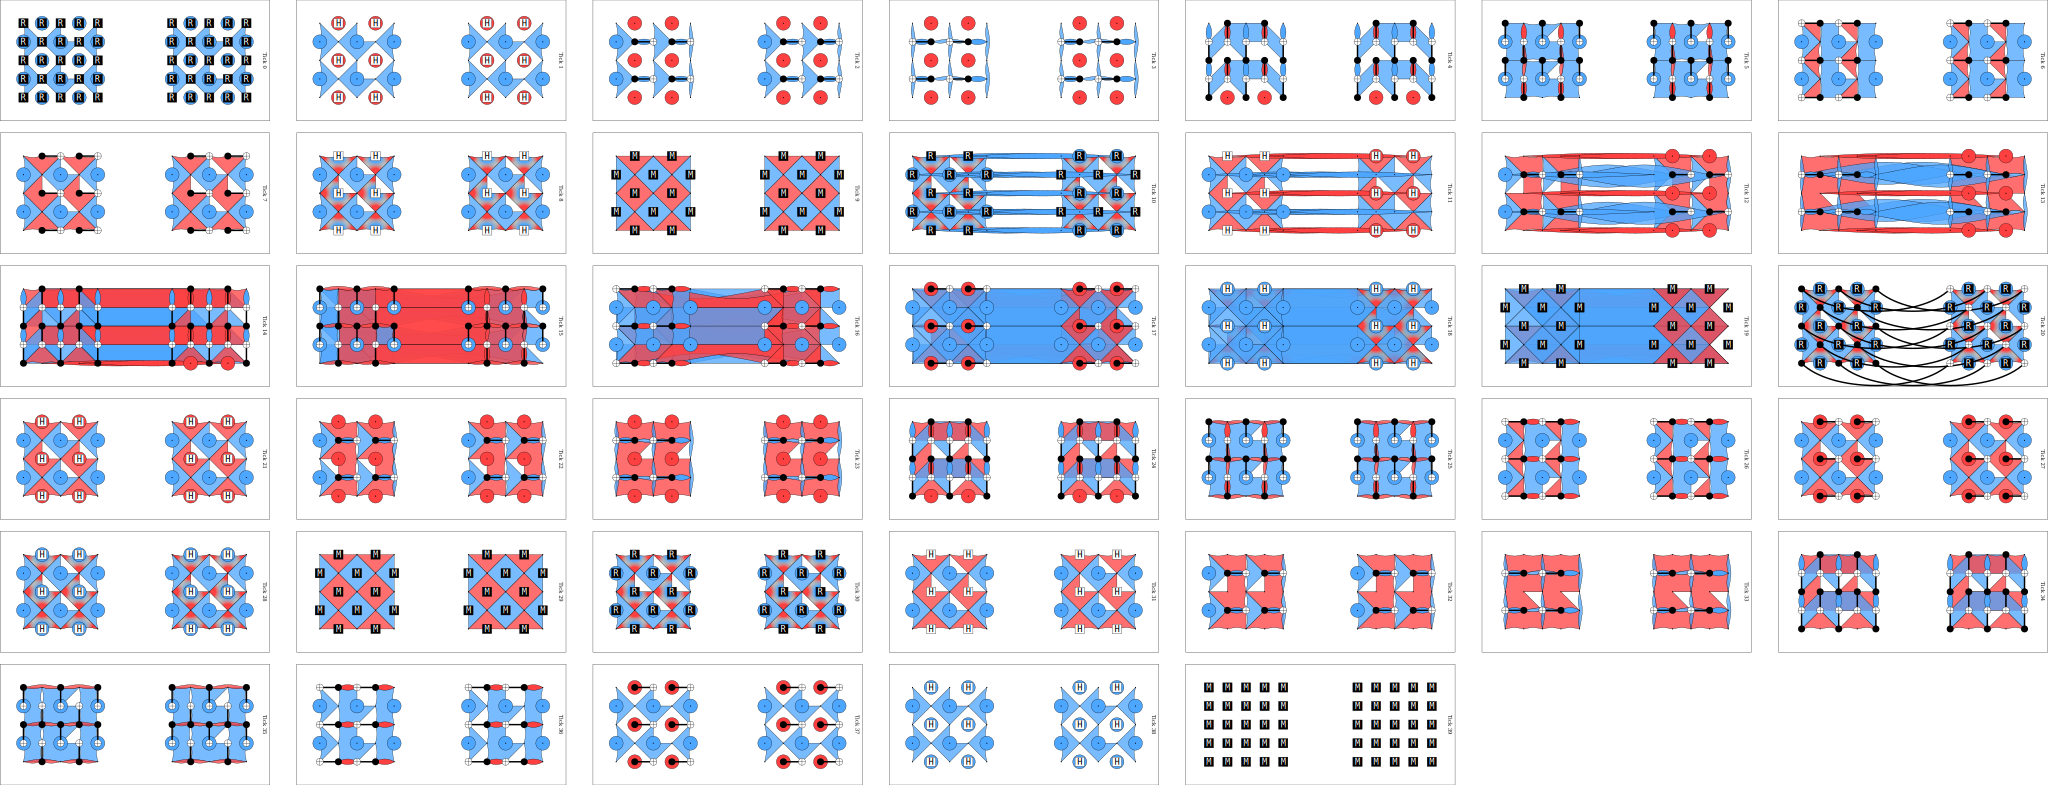

In [4]:
circuits["ZZ_ZZ"].without_noise().diagram("detslice-with-ops-svg")

## Noiseless Sanity Check

In [5]:
for sub, circ in circuits.items():
    sampler = circ.without_noise().compile_detector_sampler()
    det, obs = sampler.sample(shots=200, separate_observables=True)
    print(f"{sub}: clean={not det.any() and not obs.any()}")

ZZ_ZZ: clean=True
ZX_ZX: clean=True
XZ_XX: clean=True
XZ_ZZ: clean=True
XX_XX: clean=True


## Simulation with BP+OSD (100k shots each)

BP+OSD is used because transversal CNOT introduces non-CSS detector correlations.

In [6]:
pipeline = SimulationPipeline(
    decoder_config=DecoderConfig("bposd", backend="cpu"),
    max_shots=100_000,
    max_errors=50,
    num_workers=4,
    print_progress=False,
)

results = {}
for sub, circ in circuits.items():
    stats = pipeline.run(circ)
    results[sub] = stats
    print(f"{sub}: LER={stats.logical_error_rate:.2e}  ({stats.errors} errors / {stats.shots:,} shots)")

ZZ_ZZ: LER=2.05e-03  (123 errors / 60,000 shots)


ZX_ZX: LER=1.97e-03  (118 errors / 60,000 shots)


XZ_XX: LER=1.61e-03  (113 errors / 70,000 shots)


XZ_ZZ: LER=1.36e-03  (109 errors / 80,000 shots)


XX_XX: LER=2.03e-03  (122 errors / 60,000 shots)
